# **05 메타데이터 필터링 (Qdrant)**

### 학습 내용
1. 메타데이터의 개념과 활용
2. 목차 기반 카테고리 메타데이터 추가
3. Qdrant 필터 문법을 활용한 검색
4. "육아 정책 알려줘" → "아이돌봄" 카테고리만 검색
5. 필터링을 활용한 정교한 RAG 구현

**데이터**: 2026 달라지는 천안 새로운 변화.pdf (목차 기반 메타데이터)

## 0. 환경 변수 설정

이 실습은 Qdrant Cloud를 사용합니다.

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

# .env는 노트북 파일이 아니라 Jupyter 커널의 현재 폴더를 기준으로 찾습니다.
env_candidates = [
    Path.cwd() / ".env",
    Path.cwd().parent / ".env",
    Path.cwd() / "smu-ai-service-bootcamp" / "rag-system" / ".env",
    Path.cwd() / "rag-system" / ".env",
]
env_path = next((path for path in env_candidates if path.is_file()), None)

if env_path is None:
    print("✗ .env 파일을 찾을 수 없습니다.")
else:
    load_dotenv(dotenv_path=env_path)
    print(f"환경 변수 파일: {env_path.resolve()}")

# API Key 확인
if os.environ.get("OPENAI_API_KEY"):
    print("✓ OpenAI API Key가 설정되었습니다.")
else:
    print("✗ OpenAI API Key가 없습니다.")

# Qdrant Cloud 설정 확인
if os.environ.get("QDRANT_URL") and os.environ.get("QDRANT_API_KEY"):
    print("✓ Qdrant Cloud 설정이 완료되었습니다.")
    print(f"  URL: {os.environ.get('QDRANT_URL')}")
else:
    print("✗ Qdrant Cloud 설정이 필요합니다.")
    print("  .env 파일에 QDRANT_URL과 QDRANT_API_KEY를 추가하세요.")

환경 변수 파일: C:\Users\taehy\Desktop\인공지능 기반 상명 AI Training\smu-ai-service-bootcamp\rag-system\.env
✓ OpenAI API Key가 설정되었습니다.
✓ Qdrant Cloud 설정이 완료되었습니다.
  URL: https://14aa4220-1d44-461a-b29e-a4effdecccae.eu-west-2-0.aws.cloud.qdrant.io:6333


In [2]:
# .env 파일 로드
load_dotenv()

# API 키 확인
api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    print("OPENAI_API_KEY가 정상적으로 로드되었습니다.")
    print("API Key ?? ???? ????.")
else:
    print("OPENAI_API_KEY를 찾을 수 없습니다.")
    print(".env 파일을 생성하고 OPENAI_API_KEY를 설정해주세요.")

OPENAI_API_KEY가 정상적으로 로드되었습니다.
API Key: sk-proj-yw...K00A


## 1. 메타데이터란?

**메타데이터(Metadata)**: 데이터에 대한 데이터

문서의 메타데이터 예시:
- 출처(source): 파일 경로, URL
- 페이지(page): 페이지 번호
- 저자(author): 작성자
- 날짜(date): 작성/수정 날짜
- 카테고리(category): 문서 분류
- 언어(language): 문서 언어

### 메타데이터의 활용

1. **필터링**: 특정 조건의 문서만 검색
2. **분류**: 문서를 카테고리별로 관리
3. **출처 추적**: 답변의 근거 제시
4. **시간 제한**: 최신 문서만 검색

## 2. 천안시 PDF 로딩 및 목차 기반 메타데이터 추가

"2026 달라지는 천안 새로운 변화.pdf"는 가로형 PDF로, 좌표 기반 분할이 필요합니다.
목차에 있는 카테고리를 메타데이터로 추가하여 정확한 필터링을 구현합니다.

### 2-1. 카테고리 정의 (목차 기반)

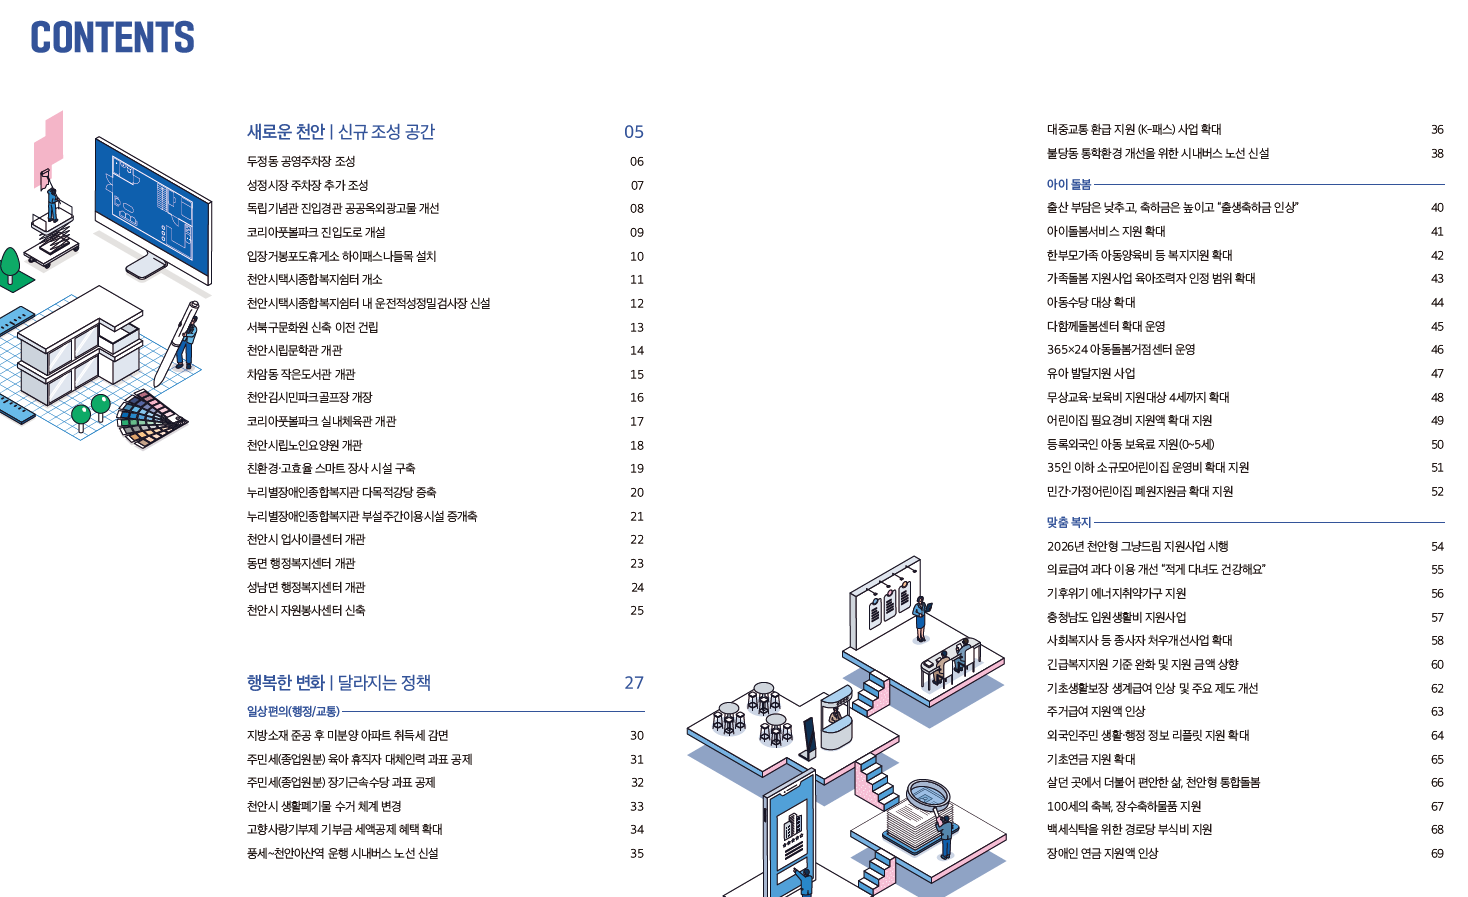

```text
카테고리 구조:
  - 새로운_천안_신규_조성_공간 (4R ~ 14R)
  - 행복한_변화_달라지는_정책 (15R ~ 49L)
    ├ 일상편의_행정_교통 (16R ~ 21L)
    ├ 아이돌봄 (21R ~ 28L)
    ├ 맞춤_복지 (28R ~ 37R)
    ├ 건강_내일_보건 (38R ~ 43R)
    └ 문화_관광 (44R ~ 49L)
  - 즐거운_일상_행사축제 (49R ~ 51R)
```

In [3]:
from langchain_core.documents import Document
import fitz

# 목차 기반 카테고리 정의 (페이지 범위별)
def get_category(page_num, sub_page):
    """
    페이지 번호와 sub_page(left/right)로 카테고리 결정
    목차 구조:
    - 새로운 천안 | 신규 조성 공간: 4(Right) ~ 14(Right) 페이지
    - 행복한 변화 | 달라지는 정책: 15(Right) ~ 49(Left) 페이지
      - 일상편의(행정/교통): 16(Right) ~ 21(Left) 페이지
      - 아이돌봄: 21(Right) ~ 28(Left) 페이지
      - 맞춤복지: 28(Right) ~ 37(Right) 페이지
      - 건강 내일(보건): 38(Right) ~ 43(Right) 페이지
      - 문화 관광: 44(Right) ~ 49(Left) 페이지
    - 함께 누리는 즐거운 일상 | 2026 주요 행사·축제: 49(Right) ~ 51(Right) 페이지
    """
    # 새로운 천안 | 신규 조성 공간
    if (page_num == 4 and sub_page == "right") or \
       (5 <= page_num <= 13) or \
       (page_num == 14 and sub_page in ["left", "right"]):
        return "새로운_천안_신규_조성_공간"

    # 행복한 변화 | 달라지는 정책 (세부 카테고리 포함)
    elif (page_num == 15 and sub_page == "right") or \
         (16 <= page_num <= 48) or \
         (page_num == 49 and sub_page == "left"):
        # 세부 카테고리
        if (page_num == 16 and sub_page == "right") or \
           (17 <= page_num <= 20) or \
           (page_num == 21 and sub_page == "left"):
            return "일상편의_행정_교통"
        elif (page_num == 21 and sub_page == "right") or \
             (22 <= page_num <= 27) or \
             (page_num == 28 and sub_page == "left"):
            return "아이돌봄"
        elif (page_num == 28 and sub_page == "right") or \
             (29 <= page_num <= 37):
            return "맞춤_복지"
        elif (page_num == 38 and sub_page == "right") or \
             (39 <= page_num <= 43):
            return "건강_내일_보건"
        elif (page_num == 44 and sub_page == "right") or \
             (45 <= page_num <= 48) or \
             (page_num == 49 and sub_page == "left"):
            return "문화_관광"
        else:
            return "행복한_변화_달라지는_정책"

    # 함께 누리는 즐거운 일상 | 2026 주요 행사·축제
    elif (page_num == 49 and sub_page == "right") or \
         (50 <= page_num <= 51):
        return "즐거운_일상_행사축제"

    else:
        return "기타"

In [4]:
file_path = "../datasets/2026 달라지는 천안 새로운 변화.pdf"

doc = fitz.open(file_path)
docs = []

# 가로형 PDF 처리 (좌표 기반 분할)
for page_num in range(len(doc)):
    page = doc[page_num]
    rect = page.rect

    # 페이지를 좌우로 분할
    mid_x = rect.width / 2
    left_rect = fitz.Rect(0, 0, mid_x, rect.height)
    right_rect = fitz.Rect(mid_x, 0, rect.width, rect.height)

    # 왼쪽 페이지
    left_text = page.get_text("text", clip=left_rect, sort=True)
    if len(left_text.strip()) >= 10:
        docs.append(
            Document(
                page_content=left_text,
                metadata={
                    "source": "2026 달라지는 천안 새로운 변화.pdf",
                    "page": page_num + 1,
                    "sub_page": "left",
                    "category": get_category(page_num + 1, "left"),
                    "doc_type": "policy_guide",
                    "publisher": "천안시",
                    "year": 2026,
                    "language": "ko"
                }
            )
        )

    # 오른쪽 페이지
    right_text = page.get_text("text", clip=right_rect, sort=True)
    if len(right_text.strip()) >= 10:
        docs.append(
            Document(
                page_content=right_text,
                metadata={
                    "source": "2026 달라지는 천안 새로운 변화.pdf",
                    "page": page_num + 1,
                    "sub_page": "right",
                    "category": get_category(page_num + 1, "right"),
                    "doc_type": "policy_guide",
                    "publisher": "천안시",
                    "year": 2026,
                    "language": "ko"
                }
            )
        )

doc.close()

print(f"총 {len(docs)}개의 문서 생성 완료")
print(f"\n첫 번째 문서 메타데이터:")
for key, value in docs[0].metadata.items():
    print(f"  - {key}: {value}")

총 93개의 문서 생성 완료

첫 번째 문서 메타데이터:
  - source: 2026 달라지는 천안 새로운 변화.pdf
  - page: 1
  - sub_page: right
  - category: 기타
  - doc_type: policy_guide
  - publisher: 천안시
  - year: 2026
  - language: ko


### 2-2. 카테고리별 문서 수 확인

In [5]:
from collections import Counter

categories = [doc.metadata['category'] for doc in docs]
category_counts = Counter(categories)

print("카테고리별 문서 수:")
for category, count in sorted(category_counts.items()):
    print(f"  - {category}: {count}개")

print(f"\n'아이돌봄' 카테고리: {category_counts.get('아이돌봄', 0)}개 (육아 정책)")

카테고리별 문서 수:
  - 건강_내일_보건: 11개
  - 기타: 5개
  - 맞춤_복지: 18개
  - 문화_관광: 9개
  - 새로운_천안_신규_조성_공간: 21개
  - 아이돌봄: 13개
  - 일상편의_행정_교통: 10개
  - 즐거운_일상_행사축제: 5개
  - 행복한_변화_달라지는_정책: 1개

'아이돌봄' 카테고리: 13개 (육아 정책)


## 3. Qdrant Cloud 벡터스토어 구축

In [6]:
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams, PayloadSchemaType
from uuid import uuid4

# Qdrant Cloud 클라이언트 생성
client = QdrantClient(
    url=os.getenv("QDRANT_URL"),
    api_key=os.getenv("QDRANT_API_KEY")
)

print("Qdrant Cloud에 연결되었습니다.")

# 임베딩 함수
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

# 컬렉션 생성
collection_name = "cheonan_metadata"

# 컬렉션 존재 여부 확인
collections = client.get_collections().collections
existing_collection = any(col.name == collection_name for col in collections)

if existing_collection:
    print(f"컬렉션 '{collection_name}'이 이미 존재합니다.")
    user_input = input("기존 데이터를 삭제하고 새로 추가하시겠습니까? (y/n): ")

    if user_input.lower() == 'y':
        print(f"컬렉션 '{collection_name}' 삭제 중...")
        client.delete_collection(collection_name=collection_name)
        print("컬렉션이 삭제되었습니다.")

        # 컬렉션 재생성
        client.create_collection(
            collection_name=collection_name,
            vectors_config=VectorParams(size=3072, distance=Distance.COSINE)
        )
        print(f"컬렉션 '{collection_name}' 생성 완료")

        # 메타데이터 필터링을 위한 인덱스 생성
        print("메타데이터 필드 인덱스 생성 중...")
        client.create_payload_index(
            collection_name=collection_name,
            field_name="metadata.category",
            field_schema=PayloadSchemaType.KEYWORD
        )
        client.create_payload_index(
            collection_name=collection_name,
            field_name="metadata.page",
            field_schema=PayloadSchemaType.INTEGER
        )
        client.create_payload_index(
            collection_name=collection_name,
            field_name="metadata.source",
            field_schema=PayloadSchemaType.KEYWORD
        )
        client.create_payload_index(
            collection_name=collection_name,
            field_name="metadata.year",
            field_schema=PayloadSchemaType.INTEGER
        )
        print("인덱스 생성 완료")
    else:
        print("기존 컬렉션을 사용합니다.")
else:
    # 컬렉션이 없으면 새로 생성
    client.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=3072, distance=Distance.COSINE)
    )
    print(f"컬렉션 '{collection_name}' 생성 완료")

    # 메타데이터 필터링을 위한 인덱스 생성
    print("메타데이터 필드 인덱스 생성 중...")
    client.create_payload_index(
        collection_name=collection_name,
        field_name="metadata.category",
        field_schema=PayloadSchemaType.KEYWORD
    )
    client.create_payload_index(
        collection_name=collection_name,
        field_name="metadata.page",
        field_schema=PayloadSchemaType.INTEGER
    )
    client.create_payload_index(
        collection_name=collection_name,
        field_name="metadata.source",
        field_schema=PayloadSchemaType.KEYWORD
    )
    client.create_payload_index(
        collection_name=collection_name,
        field_name="metadata.year",
        field_schema=PayloadSchemaType.INTEGER
    )
    print("인덱스 생성 완료")

Qdrant Cloud에 연결되었습니다.
컬렉션 'cheonan_metadata'이 이미 존재합니다.
컬렉션 'cheonan_metadata' 삭제 중...
컬렉션이 삭제되었습니다.
컬렉션 'cheonan_metadata' 생성 완료
메타데이터 필드 인덱스 생성 중...
인덱스 생성 완료


In [7]:
# 벡터스토어 생성
vectorstore = QdrantVectorStore(
    client=client,
    collection_name=collection_name,
    embedding=embeddings
)

vectorstore.add_documents(documents=docs)

print(f"\n{len(docs)}개의 문서가 Qdrant Cloud에 추가되었습니다.")


93개의 문서가 Qdrant Cloud에 추가되었습니다.


## 4. Qdrant 메타데이터 필터링 검색

### 4-1. 기본 검색 (필터 없음)

In [8]:
query = "천안시 정책"

# 필터 없이 검색
results = vectorstore.similarity_search(query, k=5)

print(f"검색 쿼리: {query}")
print(f"\n[필터 없음] {len(results)}개 결과\n")

for i, doc in enumerate(results, start=1):
    print(f"{i}. 페이지 {doc.metadata['page']}, 카테고리: {doc.metadata['category']}")
    print(f"   내용: {doc.page_content}\n")

검색 쿼리: 천안시 정책

[필터 없음] 5개 결과

1. 페이지 3, 카테고리: 기타
   내용: CONTENTS




               새로운 천안 | 신규 조성 공간                   05

                     두정동 공영주차장 조성                                        06

                     성정시장 주차장 추가 조성                                       07

                     독립기념관 진입경관 공공옥외광고물 개선                           08

                     코리아풋볼파크 진입도로 개설                                   09

                     입장거봉포도휴게소 하이패스나들목 설치                            10

                     천안시택시종합복지쉼터 개소                                    11

                     천안시택시종합복지쉼터 내 운전적성정밀검사장 신설                    12

                     서북구문화원 신축 이전 건립                                    13

                     천안시립문학관 개관                                          14

                     차암동 작은도서관 개관                                        15

                     천안김시민파크골프장 개장                                     16

                     코리아풋볼파크 실내체육관 개관            

### 4-2. 카테고리 필터링 - "아이돌봄" (육아 정책)

"육아에 관한 정책 알려줘" → "아이돌봄" 카테고리만 검색

In [9]:
from qdrant_client import models

results = vectorstore.similarity_search(
    "아이 정서 관련",
    k=5,
    filter=models.Filter(
        must=[
            models.FieldCondition(
                key="metadata.category",
                match=models.MatchValue(value="아이돌봄")
            )
        ]
    )
)

print(f"검색 쿼리: 육아 정책")
print(f"필터: category = '아이돌봄'")
print(f"\n[필터 적용] {len(results)}개 결과\n")

for i, doc in enumerate(results, start=1):
    print(f"{i}. 페이지 {doc.metadata['page']} ({doc.metadata.get('sub_page', '?')}), 카테고리: {doc.metadata['category']}")
    print(f"   내용: {doc.page_content}\n")
    print("="*80 + "\n")

검색 쿼리: 육아 정책
필터: category = '아이돌봄'

[필터 적용] 5개 결과

1. 페이지 25 (right), 카테고리: 아이돌봄
   내용:                                                   시행일 2026. 01. 01.


 유아 발달지원         정서·행동 등 발달에 어려움을 겪는 유아의 건강한
                     성장을 지원하고, 양육정보와 상담을 제공함으로써
 사업                보호자의 양육 역량 강화를 지원합니다.





새롭게            발달에 어려움을 겪는 유아의 건강한 성장을 지원
시작해요         •관내 어린이집 3세~5세 유아

              •관내 유아반 담임교사와 보호자 대상 발달 검사 및 상담




더 자세히         •지원대상 | 관내 어린이집 3~5세 유아
알려드립니다              •지원내용 | 관내 유아반 담임교사와 보호자 대상 발달 검사 및 상담

              •신청방법 | 천안시육아종합지원센터(www.ceic.or.kr) 온라인 신청

              •지원절차

                  신청·접수 → 영유아 선정 → 발달검사 → 부모/교사 면담(솔루션제공) → 만족도 조사

              •제공기관 | 천안육아종합지원센터 041-561-2821

              •기대효과

               발달검사를 통해 지연 여부를 조기에 확인하고 적절한 양육·보육 정보 제공을

               통한 건강한 성장과 발달 도모




담당부서         아동보육과 보육정책팀 041-521-3666





                                                                         2026 달라지는 천안 새로운 변화 | 47


2. 페이지 24 (left), 카테고리: 아이돌봄


### 4-3. 복합 필터링 (OR 조건)

여러 카테고리를 동시에 검색 - Qdrant의 `should` 사용

In [10]:
# '아이돌봄' 또는 '맞춤_복지' 카테고리
results = vectorstore.similarity_search(
    "임신 관련 휴가",
    k=5,
    filter=models.Filter(
        should=[
            models.FieldCondition(
                key="metadata.category",
                match=models.MatchValue(value="아이돌봄")
            ),
            models.FieldCondition(
                key="metadata.category",
                match=models.MatchValue(value="맞춤_복지")
            )
        ]
    )
)

print(f"필터: category = '아이돌봄' OR '맞춤_복지'")
print(f"\n{len(results)}개 결과\n")

for i, doc in enumerate(results, start=1):
    print(f"{i}. 페이지 {doc.metadata['page']}, 카테고리: {doc.metadata['category']}")
    print(f"   내용: {doc.page_content}\n")
    print("="*80 + "\n")

필터: category = '아이돌봄' OR '맞춤_복지'

5개 결과

1. 페이지 31, 카테고리: 맞춤_복지
   내용: 더 자세히         •지원대상 | 관내 사회복지시설 등 종사자
알려드립니다        ※ 사업별 지원대상 상이

              •지원내용


                      구분                    내용

                       장기근속휴가  •3년 이상 근속자 장기근속 휴가 부여(3일~15일 차등)

                              •(난임치료시술 휴가) 여성 2~4일, 남성 1일
                 근무환경 가족친화 특별휴가
                                   •(임신검진 휴가) 임신기간 중 10일
                 개선
                              •반기별 총량범위 내 개인별 시간외근무수당 탄력 운영·적용
                      시간외근무 총량제
                                                               - 월별 예산편성시간×6개월 한도(반기 내 잔여시간 이월 가능)

                              •호봉에 따른 차등 지급(타시설 경력 인정)

                       복지포인트       - 생활시설 5년 이상 200천원, 10년 이상 300천원

                                                               - 이용시설 10년 이상 200천원
                 복리후생
                              •사회복지사 등 종사자를 위한 기획공연 운영
                 지원  찾아가는 문화공연
                                                 

### 4-4. 페이지 범위 필터링

특정 페이지 범위 검색 - Qdrant의 range 조건 사용

아이돌봄 카테고리 페이지 범위: 21(Right) ~ 28(Left)

In [11]:
# 페이지 범위 필터링 (21-28 페이지: 아이돌봄 카테고리)
results = vectorstore.similarity_search(
    "육아 정책",
    k=5,
    filter=models.Filter(
        must=[
            models.FieldCondition(
                key="metadata.page",
                range=models.Range(
                    gte=21,   # 페이지 >= 21
                    lte=28    # 페이지 <= 28
                )
            )
        ]
    )
)

print(f"필터: 21 <= page <= 28 (아이돌봄 페이지)")
print(f"\n{len(results)}개 결과\n")

for i, doc in enumerate(results, start=1):
    print(f"{i}. 페이지 {doc.metadata['page']} ({doc.metadata.get('sub_page', '?')}), 카테고리: {doc.metadata['category']}")

필터: 21 <= page <= 28 (아이돌봄 페이지)

5개 결과

1. 페이지 25 (right), 카테고리: 아이돌봄
2. 페이지 26 (left), 카테고리: 아이돌봄
3. 페이지 23 (right), 카테고리: 아이돌봄
4. 페이지 23 (left), 카테고리: 아이돌봄
5. 페이지 26 (right), 카테고리: 아이돌봄


### 4-5. 필터만 사용 (유사도 검색 없음)

`scroll()` 메서드를 사용하면 벡터 유사도 검색 없이 **필터 조건만으로** 데이터를 조회할 수 있습니다.

**활용 사례**:
- 특정 페이지의 모든 데이터 가져오기
- 특정 카테고리의 전체 문서 목록 조회
- 메타데이터 기반 데이터 탐색

In [12]:
# scroll() 메서드: 유사도 검색 없이 필터만으로 데이터 조회
# 아이돌봄 카테고리의 모든 문서 가져오기

records, next_offset = client.scroll(
    collection_name=collection_name,
    scroll_filter=models.Filter(
        must=[
            models.FieldCondition(
                key="metadata.category",
                match=models.MatchValue(value="아이돌봄")
            )
        ]
    ),
    limit=10,  # 한 번에 가져올 최대 문서 수
    with_payload=True,  # 메타데이터 포함
    with_vectors=False  # 벡터는 가져오지 않음 (필요 없으면)
)

print(f"필터: category = '아이돌봄'")
print(f"\n{len(records)}개 문서 조회\n")

for i, record in enumerate(records, start=1):
    page = record.payload.get('metadata', {}).get('page', '?')
    sub_page = record.payload.get('metadata', {}).get('sub_page', '?')
    category = record.payload.get('metadata', {}).get('category', '?')
    content = record.payload.get('page_content', '')

    print(f"{i}. 페이지 {page} ({sub_page}), 카테고리: {category}")
    print(f"   내용: {content}")
    print()

필터: category = '아이돌봄'

10개 문서 조회

1. 페이지 25 (left), 카테고리: 아이돌봄
   내용:                                                   시행일 2026. 01. 01.


  365×24 아동돌봄거점센터
 운영





이렇게                  변경전                  변경후
달라져요
                          2025년 1개소 운영                2026년 3개소 확대 운영





더 자세히         •확대
알려드립니다           2026년 3개소 확대 운영

                  (구성동)온누리마을돌봄터, (쌍용동)미래지역아동센터, (두정동)새하늘지역아동센터

              •지원대상

               돌봄이 필요한 6~12세(초등학생) 아동 / 소득 수준 무관

                     (*이용료(시간당) 1,000원)

              •지원내용

               기존 아동돌봄시설을 활용, 아동돌봄거점센터를 지정하여 아침, 야간, 주말·공휴일

               돌봄 및 수요자 필요시 긴급·일시돌봄 제공

              •운영시간

               학기 중(20:00~익일09:00), 방학 중(18:00~익일09:00), 주말·공휴일(09:00~ 18:00)

              •신청방법 | 사전 예약(“아이충남” https://www.ichungnam.kr 온라인 또는 전화 예약)




담당부서         아동보육과 아동복지정책팀 041-521-3664





46

2. 페이지 25 (right), 카테고리: 아이돌봄
   내용:                                                   시행일 2026. 01. 01.


 유아 발달지원         정서·행동 

In [13]:
# scroll() + 페이지 범위 필터
# 22-25 페이지의 모든 문서 가져오기

records, next_offset = client.scroll(
    collection_name=collection_name,
    scroll_filter=models.Filter(
        must=[
            models.FieldCondition(
                key="metadata.page",
                range=models.Range(gte=22, lte=25)
            )
        ]
    ),
    limit=20,
    with_payload=True,
    with_vectors=False
)

print(f"필터: 22 <= page <= 25")
print(f"{len(records)}개 문서 조회\n")

for i, record in enumerate(records, start=1):
    page = record.payload.get('metadata', {}).get('page', '?')
    sub_page = record.payload.get('metadata', {}).get('sub_page', '?')
    category = record.payload.get('metadata', {}).get('category', '?')

    print(f"{i}. 페이지 {page} ({sub_page}), 카테고리: {category}")

필터: 22 <= page <= 25
8개 문서 조회

1. 페이지 25 (left), 카테고리: 아이돌봄
2. 페이지 25 (right), 카테고리: 아이돌봄
3. 페이지 23 (right), 카테고리: 아이돌봄
4. 페이지 24 (left), 카테고리: 아이돌봄
5. 페이지 22 (left), 카테고리: 아이돌봄
6. 페이지 23 (left), 카테고리: 아이돌봄
7. 페이지 22 (right), 카테고리: 아이돌봄
8. 페이지 24 (right), 카테고리: 아이돌봄


| 기능 | `scroll()` | `similarity_search()` |
|------|------------|----------------------|
| 유사도 검색 | 없음 | 있음 (쿼리 벡터와 비교) |
| 정렬 순서 | 저장 순서 또는 ID 순 | 유사도 점수 순 |
| 사용 사례 | 필터 조건만으로 전체 데이터 조회 | 쿼리와 관련된 문서 검색 |
| 성능 | 빠름 (벡터 연산 없음) | 느림 (벡터 거리 계산) |
| 결과 수 | `limit` 파라미터로 제어 | `k` 파라미터로 제어 |

**언제 scroll()을 사용하나요?**
- 특정 카테고리의 모든 문서가 필요할 때
- 페이지 범위의 전체 내용을 가져올 때  
- 유사도와 관계없이 메타데이터 기반 필터링만 필요할 때
- 데이터 탐색 및 분석 목적

### 4-6. 복합 조건 (AND + Range)

페이지 범위와 카테고리를 함께 필터링

아이돌봄 카테고리의 특정 페이지만 검색

In [14]:
# 아이돌봄 카테고리 AND 22-27 페이지 (아이돌봄 카테고리 중간 페이지)
results = vectorstore.similarity_search(
    "육아 지원",
    k=5,
    filter=models.Filter(
        must=[
            models.FieldCondition(
                key="metadata.category",
                match=models.MatchValue(value="아이돌봄")
            ),
            models.FieldCondition(
                key="metadata.page",
                range=models.Range(gte=22, lte=27)
            )
        ]
    )
)

print(f"필터: (category = '아이돌봄') AND (22 <= page <= 27)")
print(f"\n{len(results)}개 결과\n")

for i, doc in enumerate(results, start=1):
    print(f"{i}. 페이지 {doc.metadata['page']} ({doc.metadata.get('sub_page', '?')}), 카테고리: {doc.metadata['category']}")

필터: (category = '아이돌봄') AND (22 <= page <= 27)

5개 결과

1. 페이지 25 (right), 카테고리: 아이돌봄
2. 페이지 26 (left), 카테고리: 아이돌봄
3. 페이지 26 (right), 카테고리: 아이돌봄
4. 페이지 23 (right), 카테고리: 아이돌봄
5. 페이지 23 (left), 카테고리: 아이돌봄


## 5. Retriever에서 필터 사용하기

In [15]:
# Retriever with filter (아이돌봄 카테고리에서만 검색하는 Retriever 생성)
retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 3,
        "filter": models.Filter(
            must=[
                models.FieldCondition(
                    key="metadata.category",
                    match=models.MatchValue(value="아이돌봄")
                )
            ]
        )
    }
)

# Retriever로 검색
results = retriever.invoke("육아 정책")

print(f"Retriever 검색 결과 (아이돌봄 카테고리만): {len(results)}개\n")

for i, doc in enumerate(results, start=1):
    print(f"{i}. 페이지 {doc.metadata['page']}, 카테고리: {doc.metadata['category']}")
    print(f"   {doc.page_content}\n")
    print("=" * 80 + "\n")

Retriever 검색 결과 (아이돌봄 카테고리만): 3개

1. 페이지 25, 카테고리: 아이돌봄
                                                     시행일 2026. 01. 01.


 유아 발달지원         정서·행동 등 발달에 어려움을 겪는 유아의 건강한
                     성장을 지원하고, 양육정보와 상담을 제공함으로써
 사업                보호자의 양육 역량 강화를 지원합니다.





새롭게            발달에 어려움을 겪는 유아의 건강한 성장을 지원
시작해요         •관내 어린이집 3세~5세 유아

              •관내 유아반 담임교사와 보호자 대상 발달 검사 및 상담




더 자세히         •지원대상 | 관내 어린이집 3~5세 유아
알려드립니다              •지원내용 | 관내 유아반 담임교사와 보호자 대상 발달 검사 및 상담

              •신청방법 | 천안시육아종합지원센터(www.ceic.or.kr) 온라인 신청

              •지원절차

                  신청·접수 → 영유아 선정 → 발달검사 → 부모/교사 면담(솔루션제공) → 만족도 조사

              •제공기관 | 천안육아종합지원센터 041-561-2821

              •기대효과

               발달검사를 통해 지연 여부를 조기에 확인하고 적절한 양육·보육 정보 제공을

               통한 건강한 성장과 발달 도모




담당부서         아동보육과 보육정책팀 041-521-3666





                                                                         2026 달라지는 천안 새로운 변화 | 47


2. 페이지 26, 카테고리: 아이돌봄
                                    

## 📖 과제 1: 문화·관광 카테고리 전용 Retriever 만들기

**목표**: "문화_관광" 카테고리만 검색하는 Retriever를 생성하고, "천안의 문화 시설"이라는 질문으로 검색해보세요.

**요구사항**:
1. `vectorstore.as_retriever()`를 사용하여 Retriever 생성
2. `search_kwargs`에 필터 조건 추가 (`category = "문화_관광"`)
3. k=5로 설정하여 5개의 문서 검색
4. 검색 결과를 출력 (페이지 번호, 카테고리, 내용 앞 100자)

**힌트**: 위 섹션 5의 코드를 참고하여, 카테고리만 "문화_관광"으로 변경하세요.

In [16]:
# 문화_관광 카테고리에서만 검색하는 Retriever 생성
retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 5,
        "filter": models.Filter(
            must=[
                models.FieldCondition(
                    key="metadata.category",
                    match=models.MatchValue(value="문화_관광")
                )
            ]
        )
    }
)

# Retriever로 검색
results = retriever.invoke("천안의 문화 시설")

print(f"Retriever 검색 결과 (문화_관광 카테고리만): {len(results)}개\n")

# 검색 결과 출력
for i, doc in enumerate(results, start=1):
    print(
        f"{i}. 페이지 {doc.metadata['page']}, "
        f"카테고리: {doc.metadata['category']}"
    )
    print(f"   내용: {doc.page_content[:100]}")
    print("=" * 80)

Retriever 검색 결과 (문화_관광 카테고리만): 5개

1. 페이지 45, 카테고리: 문화_관광
   내용:                                                  시행일 2026. 04. 예정


 천안삼거리, 예술로 물들다    휴식과 예술이 하나로 어
2. 페이지 47, 카테고리: 문화_관광
   내용:                                                  시행일 2026. 03. 예정


 천안의 안전,               위기 앞에서 당황
3. 페이지 46, 카테고리: 문화_관광
   내용:                                                   시행일 2026. 01. 01.


 청년문화예술패스           청년의 문화 향유 
4. 페이지 47, 카테고리: 문화_관광
   내용:                                                  시행일 2026. 04. 예정


 천안 곳곳,                 타는 순간 여행
5. 페이지 48, 카테고리: 문화_관광
   내용:                  2코스  유관순 열사 테마 ②




                사적관리소          여성독립운동가        유관순 열사
         


<details>
<summary>💡 예시 답안 보기 (클릭)</summary>

```python
# 문화_관광 카테고리 전용 Retriever 생성
culture_retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 5,
        "filter": models.Filter(
            must=[
                models.FieldCondition(
                    key="metadata.category",
                    match=models.MatchValue(value="문화_관광")
                )
            ]
        )
    }
)

# 검색 실행
query = "천안의 문화 시설"
results = culture_retriever.invoke(query)

print(f"검색 쿼리: {query}")
print(f"필터: category = '문화_관광'")
print(f"\n{len(results)}개 결과\n")

for i, doc in enumerate(results, start=1):
    print(f"{i}. 페이지 {doc.metadata['page']}, 카테고리: {doc.metadata['category']}")
    print(f"   내용: {doc.page_content}")
    print()
```

</details>


---

## 6. 동적 필터링 RAG 구현

사용자 질문에 따라 적절한 카테고리 필터를 동적으로 적용하는 RAG 시스템

### 6-1. 질문 분석 함수

In [17]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from IPython.display import Markdown, display
from pydantic import BaseModel, Field
from typing import Optional

llm = init_chat_model("gpt-5.4-mini")

# 카테고리 분류 결과를 위한 Pydantic 모델
class CategoryClassification(BaseModel):
    """천안시 정책 카테고리 분류 결과"""
    category: Optional[str] = Field(
        description="선택된 카테고리 이름. 적합한 카테고리가 없으면 None"
    )

def determine_category(question: str) -> Optional[str]:
    """
    LLM을 사용하여 질문을 분석하고 적절한 천안시 카테고리 결정

    Args:
        question: 사용자 질문

    Returns:
        카테고리 이름 (문자열) 또는 None (필터 없음)
    """

    # 사용 가능한 카테고리 목록
    available_categories = {
        "새로운_천안_신규_조성_공간": "신규 시설, 공간 조성, 인프라 구축 관련",
        "일상편의_행정_교통": "행정 서비스, 교통, 주차, 도로, 편의시설 관련",
        "아이돌봄": "육아, 출산, 자녀, 돌봄, 임신, 부모, 영유아 관련",
        "맞춤_복지": "복지 지원금, 수당, 바우처, 사회복지 관련",
        "건강_내일_보건": "건강, 보건, 의료, 병원, 진료 관련",
        "문화_관광": "문화, 관광, 여행, 전시, 공연 관련",
        "즐거운_일상_행사축제": "행사, 축제, 이벤트 관련",
        "행복한_변화_달라지는_정책": "전반적인 정책 변화, 개선사항 관련"
    }

    # LLM에게 카테고리 분류 요청
    category_list = "\n".join([f"- {cat}: {desc}" for cat, desc in available_categories.items()])

    classification_prompt = f"""다음 질문을 분석하여 가장 적합한 천안시 정책 카테고리를 선택하세요.

<available_categories>
{category_list}
</available_categories>

<question>
{question}
</question>

<rules>
1. 질문의 주요 주제와 가장 관련 있는 카테고리를 선택하세요
2. 여러 카테고리가 관련될 수 있지만, 가장 핵심적인 하나만 선택하세요
3. 적합한 카테고리가 없거나 매우 일반적인 질문이면 category를 null로 설정하세요
</rules>
"""

    # Structured Output을 사용하여 LLM 호출
    structured_llm = llm.with_structured_output(CategoryClassification)
    result = structured_llm.invoke(classification_prompt)

    print(f"[LLM 분류 결과]")
    print(f"  카테고리: {result.category}")

    return result.category

In [18]:
def rag_with_dynamic_filter(question: str) -> str:
    """
    동적 필터링을 적용한 RAG
    """
    # 1. 질문 분석하여 카테고리 결정
    category = determine_category(question)

    # 2. 필터 설정
    search_kwargs = {"k": 3}
    if category:
        search_kwargs["filter"] = models.Filter(
            must=[
                models.FieldCondition(
                    key="metadata.category",
                    match=models.MatchValue(value=category)
                )
            ]
        )
        print(f"✓ 적용된 필터: category = '{category}'\n")
    else:
        print(f"✓ 필터 없음 (전체 문서 검색)\n")

    # 3. 문서 검색
    retriever = vectorstore.as_retriever(search_kwargs=search_kwargs)
    retrieved_docs = retriever.invoke(question)

    # 4. 컨텍스트 구성
    context_parts = []
    for doc in retrieved_docs:
        page = doc.metadata['page']
        cat = doc.metadata['category']
        context_parts.append(
            f"[출처: {doc.metadata['source']}, 페이지: {page}, 카테고리: {cat}]\n{doc.page_content}"
        )

    context = "\n\n---\n\n".join(context_parts)

    # 5. 프롬프트 생성
    template = """
당신은 천안시 정책 전문가입니다.
주어진 정보를 바탕으로 사용자의 질문에 정확하고 친절하게 답변하세요.
답변에 참고한 문서의 출처와 페이지 번호를 명시하세요.

<context>
{context}
</context>

<question>
{question}
</question>
"""

    prompt_template = PromptTemplate(
        input_variables=["context", "question"],
        template=template
    )

    formatted_prompt = prompt_template.format(
        context=context,
        question=question
    )

    # 6. LLM 호출
    response = llm.invoke(formatted_prompt)
    return response.content

### 6-2. 테스트

In [22]:
# 육아 정책 질문
question = "대학생에 관한 정책 알려줘"

print(f"질문: {question}\n")
answer = rag_with_dynamic_filter(question)
display(Markdown(answer))

질문: 대학생에 관한 정책 알려줘

[LLM 분류 결과]
  카테고리: 행복한_변화_달라지는_정책
✓ 적용된 필터: category = '행복한_변화_달라지는_정책'



천안시의 **대학생 관련 정책**은 자료에 따르면 **“행복한 변화(달라지는 정책)”** 범주에 포함되어 있습니다.  
다만, 현재 제공된 문서 정보에는 **대학생 정책의 구체적인 내용이 본문으로 제시되어 있지 않아** 세부 사업명이나 지원 내용까지는 확인할 수 없습니다.

### 확인 가능한 내용
- **정책 분류:** 행복한 변화
- **세부 분류:** 달라지는 정책
- **대상:** 대학생 관련 정책 포함
- **출처:** *2026 달라지는 천안 새로운 변화.pdf*, **p.15**

### 안내
정확한 대학생 정책 내용(예: 장학금, 교통비 지원, 주거 지원, 취업 지원 등)을 알려드리려면 해당 페이지의 상세 본문이나 관련 페이지가 추가로 필요합니다.  
원하시면 문서의 **대학생 관련 세부 페이지**를 보내주시면, 그 내용을 바탕으로 **정확하게 정리해드리겠습니다.**

**참고 출처:**  
- *2026 달라지는 천안 새로운 변화.pdf*, p.15

In [23]:
# 복지 정책 질문
question = "천안시 복지 지원금에 대해 알려주세요"

print(f"\n{'='*80}")
print(f"질문: {question}\n")
answer = rag_with_dynamic_filter(question)
display(Markdown(answer))


질문: 천안시 복지 지원금에 대해 알려주세요

[LLM 분류 결과]
  카테고리: 맞춤_복지
✓ 적용된 필터: category = '맞춤_복지'



천안시 복지 지원금은 **가구의 소득·재산·가구원 수 등에 따라 생계, 의료, 주거, 교육 등 다양한 급여를 지원**하는 제도입니다. 주요 내용은 아래와 같습니다.

### 1) 주급여 지원금
- **생계급여**: 가구원 수에 따라 차등 지원  
  - 1인 783,000원  
  - 2인 1,286,600원  
  - 3인 1,644,000원  
  - 4인 1,994,600원  
  - 5인 2,324,400원  
  - 6인 2,636,700원  
  - **최대 6회**
- **의료급여**: **300만원 이내**, **최대 2회**
- **주거급여**: 가구원 수에 따라 지원  
  - 1인 299,100원  
  - 2인 435,600원  
  - 3인 574,200원  
  - **최대 12회**
- **복지시설 이용급여**: 가구원 수에 따라 지원  
  - 1인 552,000원  
  - 2인 941,700원  
  - 3인 1,218,400원  
  - 4인 1,494,100원  
  - 5인 1,770,800원  
  - 6인 2,047,400원  
  - **최대 6회**
- **교육급여**:  
  - 초등학생 127.9천원  
  - 중학생 180천원  
  - 고등학생 214천원  
  - **분기별 수업료·입학금**, **최대 2회**

### 2) 부가급여
- **동절기 연료비**: 10월~3월 **15만원**, **최대 6회**
- **해산비**: **70만원**, **1회**
- **장제비**: **80만원**, **1회**
- **전기요금**: **최대 50만원 이내**, **1회**

### 참고
이 지원은 국민기초생활보장 관련 급여 성격으로, 실제 지원 여부는 **가구 상황과 자격 요건**에 따라 달라질 수 있습니다.

**출처:** 「2026 달라지는 천안 새로운 변화」 **p.32** (맞춤_복지)

In [24]:
question = "천안시의 주요 정책을 전반적으로 설명해주세요"

print(f"\n{'='*80}")
print(f"질문: {question}\n")
answer = rag_with_dynamic_filter(question)
display(Markdown(answer))


질문: 천안시의 주요 정책을 전반적으로 설명해주세요

[LLM 분류 결과]
  카테고리: 행복한_변화_달라지는_정책
✓ 적용된 필터: category = '행복한_변화_달라지는_정책'



천안시의 **주요 정책**은 시민의 생활 전반을 더 편리하고 행복하게 만들기 위한 방향으로 추진됩니다.  
주어진 자료에 따르면, 천안시는 **“행복한 변화”**를 큰 방향으로 삼고 있으며, 이는 각종 행정·복지·생활 정책이 시민 체감 중심으로 달라지고 있음을 의미합니다. 즉, 천안시의 정책은 단순한 행정 운영이 아니라 **시민 삶의 질 향상과 체감도 높은 변화**에 초점을 두고 있습니다.

다만, 현재 제공된 자료에는 구체적인 세부 정책 목록은 포함되어 있지 않고, **“행복한 변화 (달라지는 정책)”**라는 정책 방향만 확인됩니다. 따라서 이 문서만으로는 개별 정책 항목까지 상세히 설명하기는 어렵습니다.

**참고한 문서**
- **2026 달라지는 천안 새로운 변화.pdf**, **p.15**  
  - 카테고리: *행복한_변화_달라지는_정책*  
  - 내용: *행복한 변화 (달라지는 정책)*

원하시면 제가 이어서 **천안시의 분야별 주요 정책(복지, 교통, 청년, 도시, 교육 등)** 형태로 정리해드릴게요.


---

### 참고 자료

- [Qdrant Filtering 가이드](https://qdrant.tech/documentation/concepts/filtering/)
- [LangChain Qdrant 통합](https://python.langchain.com/docs/integrations/vectorstores/qdrant/)
- [Advanced RAG with Metadata](https://python.langchain.com/docs/tutorials/rag/)
- [Qdrant Python Client](https://github.com/qdrant/qdrant-client)